# RMAB ICU Allocation (Heuristic First Pass)

This notebook builds a **first-pass restless multi-armed bandit (RMAB)** for ICU allocation, aligned with your proposal:

- Each patient is an arm.
- Daily action is binary: ICU (`1`) or non-ICU (`0`).
- At most `K` **new** ICU admissions per day.
- ICU stay length is fixed at `L=7` days.
- State space is shared; transition dynamics differ by action (`P_icu`, `P_nonicu`).

This version intentionally uses a **heuristic state reward / index** so we can iterate quickly, then replace with clinically stronger definitions later.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

ROOT = Path('.')
P_ICU_PATH = ROOT / 'P_icu.npy'
P_NONICU_PATH = ROOT / 'P_nonicu.npy'


In [2]:
# Load transition matrices learned from MIMIC pipeline
assert P_ICU_PATH.exists(), f'Missing file: {P_ICU_PATH.resolve()}'
assert P_NONICU_PATH.exists(), f'Missing file: {P_NONICU_PATH.resolve()}'

P_icu = np.load(P_ICU_PATH)
P_nonicu = np.load(P_NONICU_PATH)

N_STATES = P_icu.shape[0]
DEATH_STATE = N_STATES - 1

print('P_icu shape   :', P_icu.shape)
print('P_nonicu shape:', P_nonicu.shape)
print('Death state   :', DEATH_STATE)
print('Row-sum check P_icu   min/max:', P_icu.sum(axis=1).min(), P_icu.sum(axis=1).max())
print('Row-sum check P_nonicu min/max:', P_nonicu.sum(axis=1).min(), P_nonicu.sum(axis=1).max())


P_icu shape   : (82, 82)
P_nonicu shape: (82, 82)
Death state   : 81
Row-sum check P_icu   min/max: 0.9999999999999999 1.0
Row-sum check P_nonicu min/max: 0.9999999999999999 1.0


## 1) Heuristic patient-state utility

We decode each live state (0..80) into 4 ternary bins from your existing pipeline:

- `map_bin`, `spo2_bin`, `gcs_bin`, `lactate_bin` in `{0,1,2}`
- Higher bin generally means better condition
- Death state gets the worst reward by design

We then build:

- `severity[s]` in `[0, 1]` for live states (higher = sicker)
- `reward[s]` where healthier states get larger reward, death is strongly negative


In [3]:
def decode_state_base3(s: int):
    """Decode state index into (map_bin, spo2_bin, gcs_bin, lactate_bin)."""
    map_bin = s // 27
    rem = s % 27
    spo2_bin = rem // 9
    rem = rem % 9
    gcs_bin = rem // 3
    lactate_bin = rem % 3
    return map_bin, spo2_bin, gcs_bin, lactate_bin


def build_heuristic_reward(n_states: int, death_state: int, weights=None, death_reward=-1.0):
    if weights is None:
        # Slightly higher emphasis on neuro/oxygenation for this first pass.
        weights = {'map': 1.0, 'spo2': 1.2, 'gcs': 1.3, 'lactate': 1.0}

    wsum = sum(weights.values())
    severity = np.zeros(n_states, dtype=float)
    reward = np.zeros(n_states, dtype=float)

    for s in range(n_states):
        if s == death_state:
            severity[s] = 1.0
            reward[s] = death_reward
            continue

        map_bin, spo2_bin, gcs_bin, lactate_bin = decode_state_base3(s)

        # badness: 0 is best, 2 is worst for each component
        b_map = 2 - map_bin
        b_spo2 = 2 - spo2_bin
        b_gcs = 2 - gcs_bin
        b_lac = 2 - lactate_bin

        sev = (
            weights['map'] * b_map +
            weights['spo2'] * b_spo2 +
            weights['gcs'] * b_gcs +
            weights['lactate'] * b_lac
        ) / (2.0 * wsum)

        severity[s] = sev
        reward[s] = 1.0 - sev

    return severity, reward


severity, reward = build_heuristic_reward(N_STATES, DEATH_STATE)

print('Reward range (live states):', reward[:-1].min(), reward[:-1].max())
print('Reward of death state     :', reward[DEATH_STATE])

# Quick sanity check of top/bottom states
order = np.argsort(reward[:-1])
worst5 = order[:5]
best5 = order[-5:][::-1]
print('\nWorst 5 live states:', worst5.tolist())
print('Best  5 live states:', best5.tolist())


Reward range (live states): 0.0 1.0
Reward of death state     : -1.0

Worst 5 live states: [0, 1, 27, 9, 3]
Best  5 live states: [80, 53, 79, 71, 77]


## 2) Whittle-style heuristic index

For a first usable RMAB policy, define a one-step benefit proxy:

\[
	$ext{index}(s) = \mathbb{E}[r(S_{t+1}) \mid s, a=\mathrm{ICU}] - \mathbb{E}[r(S_{t+1}) \mid s, a=\mathrm{nonICU}]$
\]

Each day, among eligible patients (alive and not currently in ICU), allocate ICU to up to `K` patients with largest index.


In [4]:
# One-step value under each action
Q_icu = P_icu @ reward
Q_nonicu = P_nonicu @ reward
index_1step = Q_icu - Q_nonicu
index_1step[DEATH_STATE] = -np.inf

print('Index stats (live states):')
print('min / median / max =', np.min(index_1step[:-1]), np.median(index_1step[:-1]), np.max(index_1step[:-1]))


Index stats (live states):
min / median / max = -0.6002258355916892 0.0 1.765497076023392


In [5]:
def default_initial_distribution(n_states: int, death_state: int):
    """Start mostly in moderate-to-good live states (no deaths at t=0)."""
    p = np.zeros(n_states, dtype=float)
    live = np.arange(n_states - 1)

    # Bias toward common moderate states seen in the transition pipeline output.
    anchors = [53, 44, 52, 50, 26]
    anchors = [s for s in anchors if s in live]

    if anchors:
        anchor_probs = np.array([0.45, 0.20, 0.15, 0.10, 0.10], dtype=float)[:len(anchors)]
        anchor_probs = anchor_probs / anchor_probs.sum()
        p[anchors] = anchor_probs
        p[:-1] += 1e-6
    else:
        p[:-1] = 1.0

    p[death_state] = 0.0
    p = p / p.sum()
    return p


def pick_admissions(states, in_icu, k_new, policy, rng):
    eligible = np.where((~in_icu) & (states != DEATH_STATE))[0]
    if len(eligible) == 0 or k_new <= 0:
        return np.array([], dtype=int)

    k = min(k_new, len(eligible))

    if policy == 'rmab_heuristic':
        scores = index_1step[states[eligible]]
        chosen = eligible[np.argsort(scores)[-k:]]
    elif policy == 'sickest_first':
        scores = severity[states[eligible]]
        chosen = eligible[np.argsort(scores)[-k:]]
    elif policy == 'random':
        chosen = rng.choice(eligible, size=k, replace=False)
    else:
        raise ValueError(f'Unknown policy: {policy}')

    return chosen


def sample_next_states(states, in_icu, rng):
    next_states = states.copy()
    for i, s in enumerate(states):
        if s == DEATH_STATE:
            next_states[i] = DEATH_STATE
            continue
        probs = P_icu[s] if in_icu[i] else P_nonicu[s]
        next_states[i] = rng.choice(N_STATES, p=probs)
    return next_states


def simulate_rmab(
    n_patients=300,
    horizon=90,
    k_new_per_day=20,
    icu_length=7,
    policy='rmab_heuristic',
    seed=0,
    init_probs=None,
):
    rng = np.random.default_rng(seed)
    if init_probs is None:
        init_probs = default_initial_distribution(N_STATES, DEATH_STATE)

    states = rng.choice(N_STATES, size=n_patients, p=init_probs)
    icu_days_remaining = np.zeros(n_patients, dtype=int)

    history = []

    for t in range(horizon):
        in_icu_before = icu_days_remaining > 0

        # Select up to K new admissions each day (proposal setting)
        admits = pick_admissions(states, in_icu_before, k_new_per_day, policy, rng)
        icu_days_remaining[admits] = icu_length

        in_icu_now = icu_days_remaining > 0

        daily_reward = reward[states].sum()
        deaths = int(np.sum(states == DEATH_STATE))
        mean_sev = float(np.mean(severity[states]))

        history.append({
            'day': t,
            'policy': policy,
            'daily_reward': daily_reward,
            'cumulative_reward': daily_reward if t == 0 else history[-1]['cumulative_reward'] + daily_reward,
            'deaths': deaths,
            'mean_severity': mean_sev,
            'icu_occupancy': int(np.sum(in_icu_now)),
            'new_admissions': int(len(admits)),
        })

        states = sample_next_states(states, in_icu_now, rng)

        icu_days_remaining = np.maximum(icu_days_remaining - 1, 0)
        icu_days_remaining[states == DEATH_STATE] = 0

    return pd.DataFrame(history)


In [6]:
# Compare policies over multiple random seeds
policies = ['rmab_heuristic', 'sickest_first', 'random']
seeds = list(range(20))

all_runs = []
for pol in policies:
    for sd in seeds:
        df = simulate_rmab(policy=pol, seed=sd)
        final = df.iloc[-1].copy()
        final['seed'] = sd
        final['avg_daily_reward'] = df['daily_reward'].mean()
        all_runs.append(final)

results = pd.DataFrame(all_runs)
summary = (
    results
    .groupby('policy')[['cumulative_reward', 'deaths', 'mean_severity', 'avg_daily_reward', 'icu_occupancy']]
    .agg(['mean', 'std'])
    .round(3)
)

summary


cumulative_reward            deaths        mean_severity  \
                            mean       std    mean    std          mean   
policy                                                                    
random                  -277.308   771.056  200.05  5.698         0.756   
rmab_heuristic         11724.464   969.302  100.15  9.304         0.520   
sickest_first           7715.703  1043.109  148.00  9.995         0.621   

                      avg_daily_reward         icu_occupancy         
                  std             mean     std          mean    std  
policy                                                               
random          0.017           -3.081   8.567         99.95  5.698  
rmab_heuristic  0.024          130.272  10.770        137.75  1.446  
sickest_first   0.028           85.730  11.590        136.55  2.139

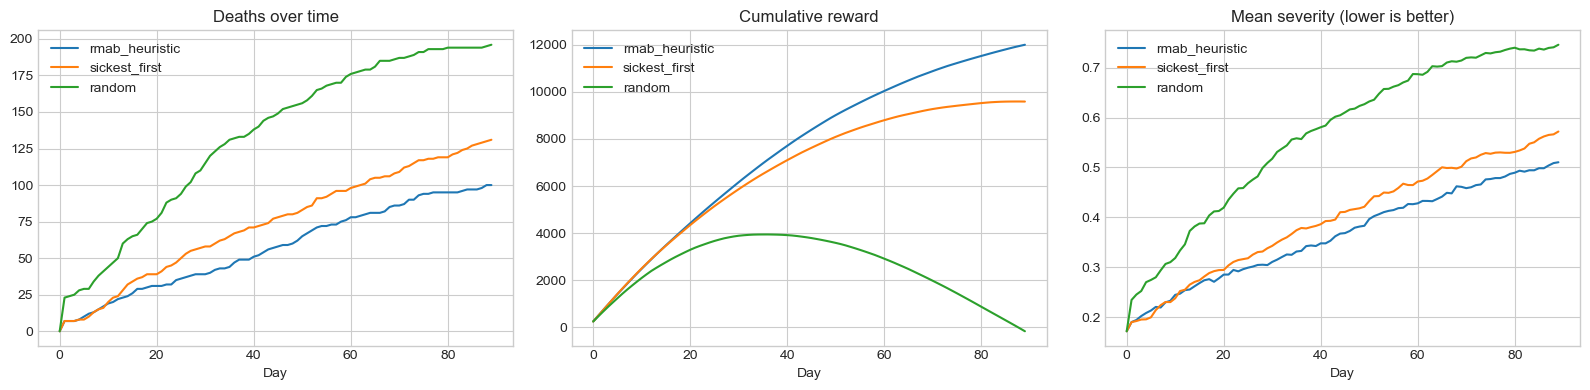

In [7]:
# Visualize one representative rollout per policy
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for pol in policies:
    traj = simulate_rmab(policy=pol, seed=0)
    axes[0].plot(traj['day'], traj['deaths'], label=pol)
    axes[1].plot(traj['day'], traj['cumulative_reward'], label=pol)
    axes[2].plot(traj['day'], traj['mean_severity'], label=pol)

axes[0].set_title('Deaths over time')
axes[1].set_title('Cumulative reward')
axes[2].set_title('Mean severity (lower is better)')

for ax in axes:
    ax.set_xlabel('Day')
    ax.legend()

plt.tight_layout()
plt.show()


## 3) Fairness hooks for next iteration

Your proposal asks to compare:

1. Model using all variables (including non-clinical)
2. Model using clinical-only variables

In the next version, we can plug in two transition pairs:

- `P_icu_all, P_nonicu_all`
- `P_icu_clinical, P_nonicu_clinical`

Then compare both utility and fairness outcomes, e.g. subgroup mortality gap or cumulative reward gap across insurance/race strata.


In [8]:
# Optional helper: quick subgroup disparity metric once you have group labels per patient

def disparity_gap(metric_a, metric_b):
    return float(metric_a - metric_b)

print('Notebook scaffold ready. Next: connect patient-level subgroup labels for fairness evaluation.')


Notebook scaffold ready. Next: connect patient-level subgroup labels for fairness evaluation.
